In [1]:
from copy import deepcopy

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy import stats
from scipy.signal import convolve2d

from tensorflow import keras
from keras.datasets import mnist
from keras import layers

!pip install icecream
from icecream import ic

rng = np.random.RandomState(1415)

# Load MNIST data

In [2]:
# Load the data and split it between train and test sets
(Xtrn, Ytrn), (Xtst, Ytst) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Visualize dataset

In [3]:
Xtrn.shape, Xtst.shape, Ytrn.shape, Ytst.shape

((60000, 28, 28), (10000, 28, 28), (60000,), (10000,))

In [4]:
np.unique(Ytrn)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

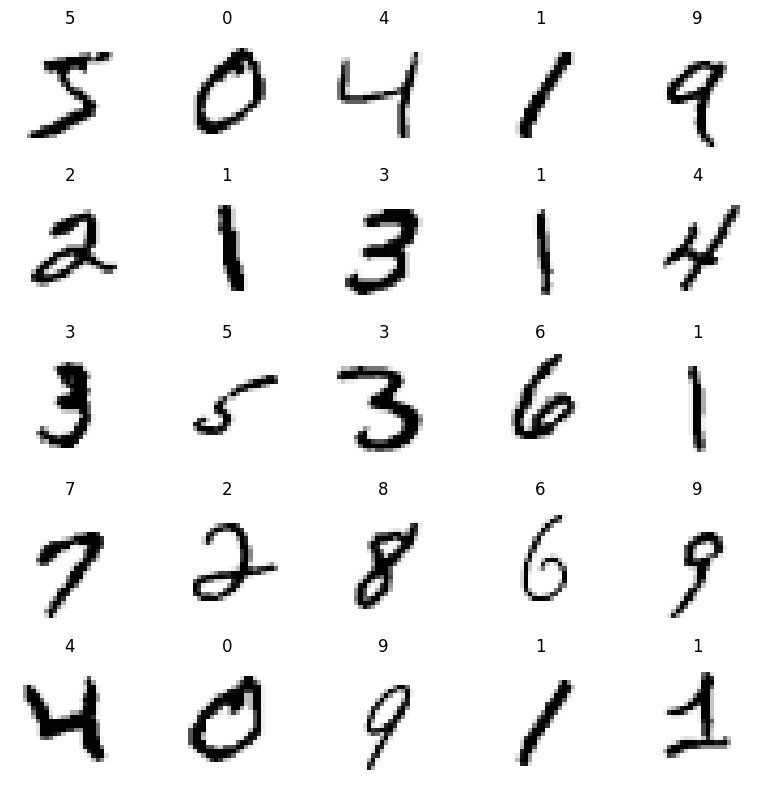

In [5]:
def plot_images(images, labels, nrows=5, ncols=5, vmin=0, vmax=255):
    fig, axes = plt.subplots(nrows, ncols, sharex=True, sharey=True, figsize=(8, 8))

    for i in range(nrows * ncols):
        ax = axes.flatten()[i]
        image = images[i]
        label = labels[i]

        ax.set_title(label)
        ax.imshow(image, vmin=vmin, vmax=vmax, cmap="Greys")
        ax.set_aspect("equal")
        ax.axis("off")

    fig.tight_layout()
    fig.show()

plot_images(Xtrn, Ytrn)

# Normalize the images

In [6]:
Xtrn.min(), Xtrn.max()

(np.uint8(0), np.uint8(255))

In [7]:
def normalize_255(array):
    normed_array = array / 255
    return normed_array

XtrnN = normalize_255(Xtrn)
XtstN = normalize_255(Xtst)

XtrnN.min(), XtrnN.max()

(np.float64(0.0), np.float64(1.0))

# Reshape the arrays for Keras

In [8]:
XtrnN.shape

(60000, 28, 28)

In [9]:
def reshape_for_keras(array):
    reshaped_array = array[..., None]
    return reshaped_array

XtrnNR = reshape_for_keras(XtrnN)
XtstNR = reshape_for_keras(XtstN)

XtrnNR.shape

(60000, 28, 28, 1)

# But wait we don't need the image labels...

### The training set will be the images at half resolution, and the model will try to up-sample the images to the original resolution... `Xtrn` should be the same 60,000 images at half resolution, but `Ytrn` should be those same images at the original resolution. We will do the same operations for the testing set.

# Construct dataset for superresolution, not image classification

In [10]:
def build_superresolution_dataset_from_mnist(X):
    Xnew = deepcopy(X)[:, ::2, ::2, :]
    Ynew = deepcopy(X)

    return Xnew, Ynew

XtrnSR, YtrnSR = build_superresolution_dataset_from_mnist(XtrnNR)
XtstSR, YtstSR = build_superresolution_dataset_from_mnist(XtstNR)

XtrnSR.shape, YtrnSR.shape, XtstSR.shape, YtstSR.shape

((60000, 14, 14, 1),
 (60000, 28, 28, 1),
 (10000, 14, 14, 1),
 (10000, 28, 28, 1))

# Visualize the new dataset

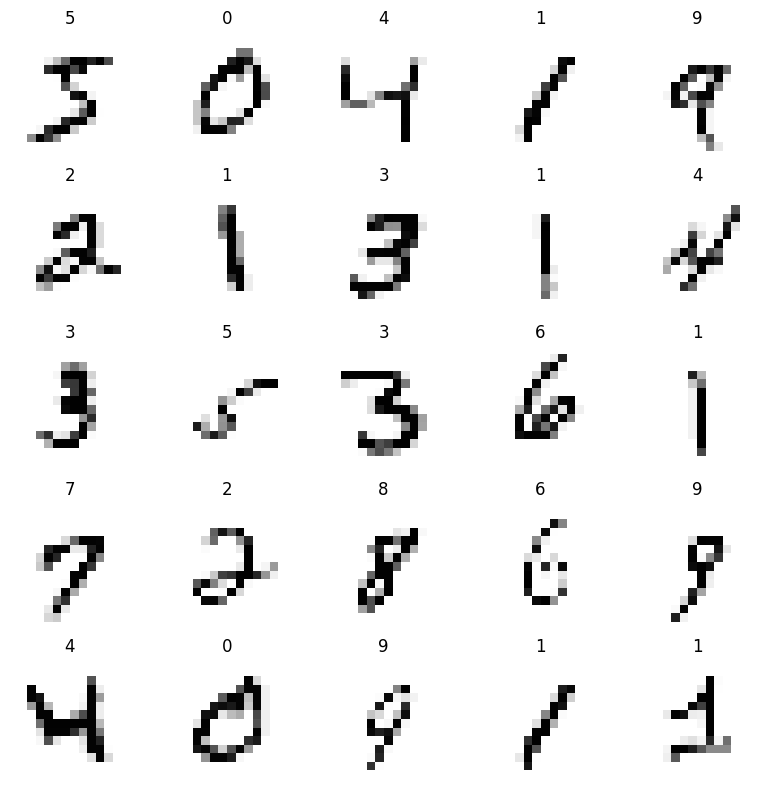

In [11]:
plot_images(XtrnSR[:, :, :, 0], Ytrn, vmax=1)

# Build the CNN autoencoder

In [12]:
def build_cnn_autoencoder(input_shape):
    inputs = layers.Input(shape=input_shape)

    # The encoder
    x = layers.Conv2D(16, kernel_size=(3, 3), padding="same", activation="relu")(inputs)
    x = layers.Conv2D(8, kernel_size=(3, 3), padding="same", activation="relu")(x)
    x = layers.Conv2D(4, kernel_size=(3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)

    shape = x.shape
    num_neurons = shape[1] * shape[2] * shape[3]

    # The latent space
    x = layers.Flatten()(x)
    LS = layers.Dense(16, activation="relu")(x)
    x = layers.Dense(num_neurons, activation="relu")(LS)
    x = layers.Reshape(shape[1:])(x)

    # The decoder
    x = layers.Conv2DTranspose(4, kernel_size=(3, 3), padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(8, kernel_size=(3, 3), padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(16, kernel_size=(3, 3), padding="same", activation="relu")(x)
    x = layers.UpSampling2D(size=(2, 2))(x)

    x = layers.Conv2DTranspose(16, kernel_size=(3, 3), padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(16, kernel_size=(3, 3), padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(16, kernel_size=(3, 3), padding="same", activation="relu")(x)
    x = layers.UpSampling2D(size=(2, 2))(x)

    x = layers.Conv2DTranspose(16, kernel_size=(3, 3), padding="same", activation="sigmoid")(x)
    x = layers.Conv2DTranspose(16, kernel_size=(3, 3), padding="same", activation="sigmoid")(x)
    outputs = layers.Conv2DTranspose(1, kernel_size=(3, 3), padding="same", activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)

    encoder = keras.Model(inputs, LS)
    decoder = keras.Model(LS, outputs)

    return model, encoder, decoder

input_shape = XtrnSR.shape[1:]
model, encoder, decoder = build_cnn_autoencoder(input_shape)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 14, 14, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 14, 14, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 4)      │           292 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 7, 7, 4)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 196)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         3,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 196)            │         3,332 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 4)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 4)        │           148 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 7, 7, 8)        │           296 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 7, 7, 16)       │         1,168 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 14, 14, 16)     │         2,320 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 14, 14, 16)     │         2,320 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 14, 14, 16)     │         2,320 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 28, 28, 16)     │         2,320 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 28, 28, 16)     │         2,320 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_8              │ (None, 28, 28, 1)      │           145 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 21,453 (83.80 KB)

 Trainable params: 21,453 (83.80 KB)

 Non-trainable params: 0 (0.00 B)

# Train the model (use a GPU)

In [13]:
model.compile(loss="mse", optimizer="adam")
history = model.fit(XtrnSR, YtrnSR, batch_size=256, epochs=15, validation_split=0.1)

Epoch 1/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - loss: 0.1661 - val_loss: 0.0812
Epoch 2/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0659 - val_loss: 0.0377
Epoch 3/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0346 - val_loss: 0.0284
Epoch 4/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0275 - val_loss: 0.0242
Epoch 5/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0241 - val_loss: 0.0226
Epoch 6/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0220 - val_loss: 0.0215
Epoch 7/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0210 - val_loss: 0.0202
Epoch 8/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0202 - val_loss: 0.0195
Epoch 9/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0195 - val_loss: 0.0189
Epoch 10/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0190 - val_loss: 0.0190
Epoch 11/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0187 - val_loss: 0.0180
Epoch 12/15
211/211 ━━━━━━━━━━━━━━━━━━━━

# Visualize loss curve

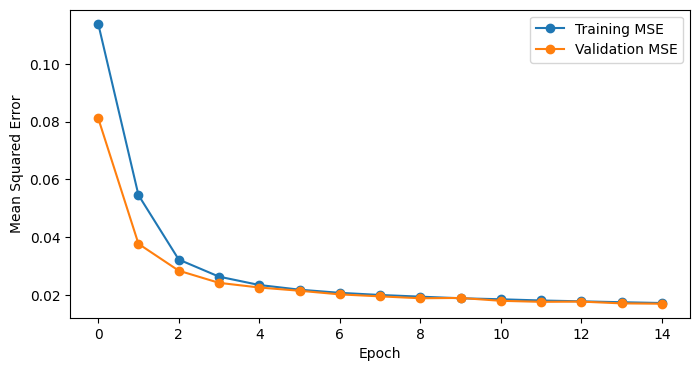

In [20]:
def loss_curves(history):
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 4))

    ax.plot(history["loss"], marker="o", label="Training MSE")
    ax.plot(history["val_loss"], marker="o", label="Validation MSE")

    ax.set_ylabel("Mean Squared Error")
    ax.set_xlabel("Epoch")

    ax.legend()

    return fig

fig = loss_curves(history.history)
fig.show()

# Visualize the predictions

In [14]:
PtstSR = model.predict(XtstSR)
PtstSR.shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


(10000, 28, 28, 1)

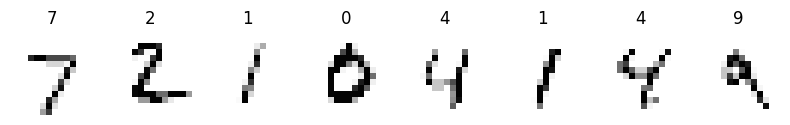

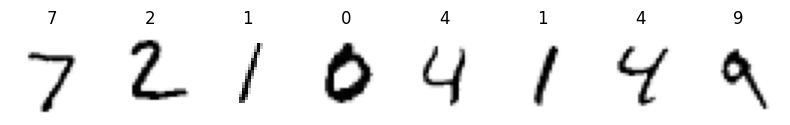

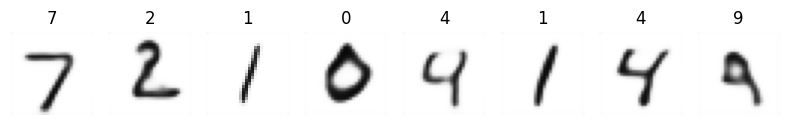

In [22]:
plot_images(XtstSR[..., 0], Ytst, nrows=1, ncols=8, vmax=1)
plot_images(YtstSR[..., 0], Ytst, nrows=1, ncols=8, vmax=1)
plot_images(PtstSR[..., 0], Ytst, nrows=1, ncols=8, vmax=1)

# Visualize the early layers

In [16]:
model.layers[1].get_weights()[0].shape

(3, 3, 1, 16)

In [33]:
def plot_kernels_on_image(image, layer, plot_kernels=False):
    kernels = layer.get_weights()[0][:, :, 0, :]
    num_kernels = kernels.shape[-1]

    fig, axes = plt.subplots(nrows=1, ncols=num_kernels, sharex=True, sharey=True, figsize=(16, 6))

    for i in range(num_kernels):
        kernel = kernels[:, :, i]
        ax = axes.flatten()[i]

        if plot_kernels:
            ax.imshow(kernel, cmap="Greys")
        else:
            convolved_image = convolve2d(image, kernel, mode='same')
            ax.imshow(convolved_image, cmap="Greys")

        ax.set_aspect("equal")
        ax.axis("off")

    fig.tight_layout()

    return fig

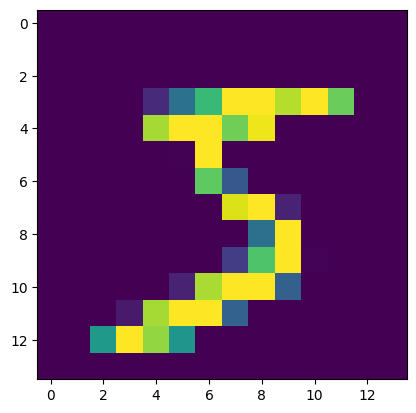

In [35]:
plt.imshow(XtrnSR[0])

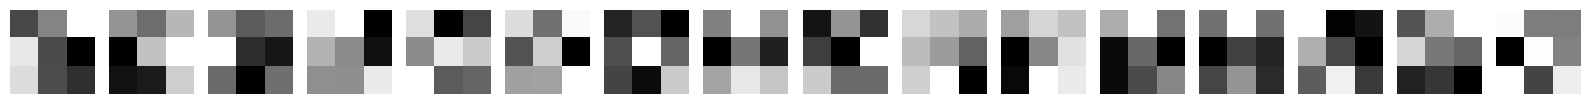

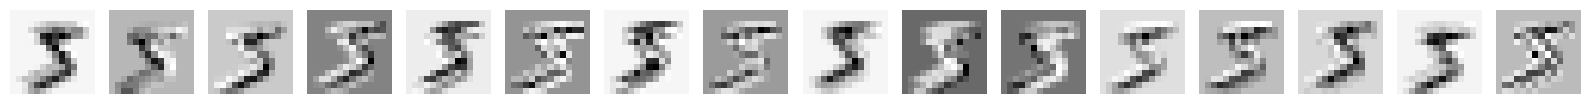

In [34]:
fig = plot_kernels_on_image(XtrnSR[0, :, :, 0], model.layers[1], plot_kernels=True)
fig.show()

fig = plot_kernels_on_image(XtrnSR[0, :, :, 0], model.layers[1])
fig.show()

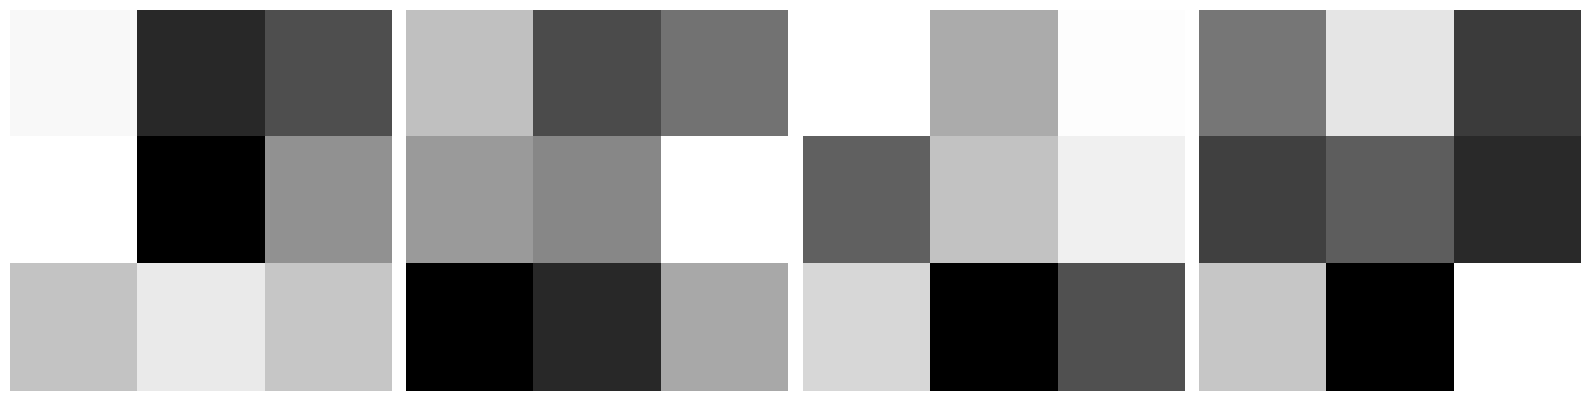

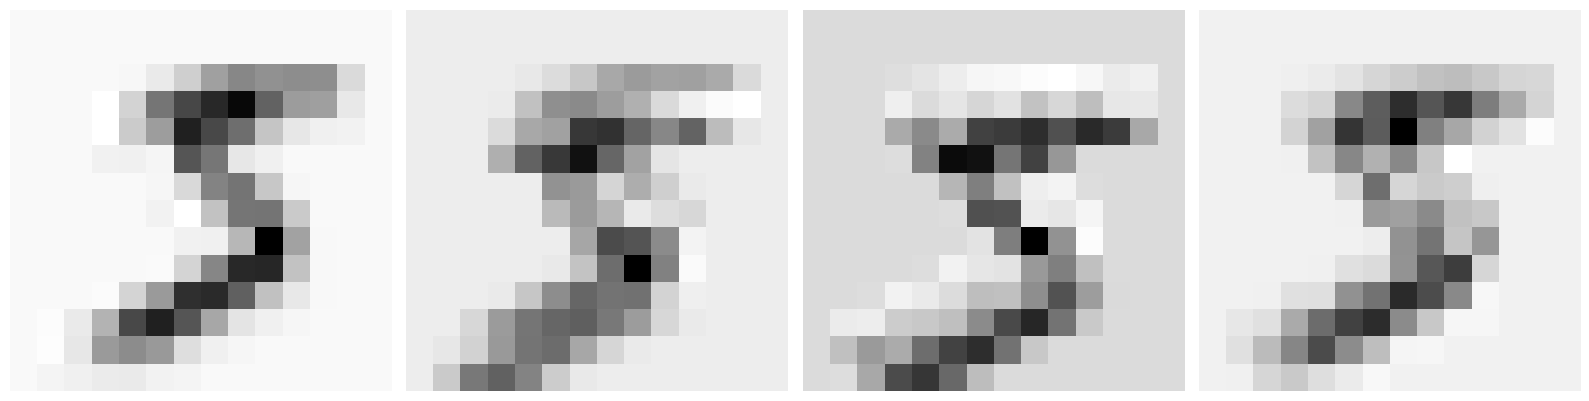

In [39]:
fig = plot_kernels_on_image(XtrnSR[0, :, :, 0], model.layers[3], plot_kernels=True)
fig.show()

fig = plot_kernels_on_image(XtrnSR[0, :, :, 0], model.layers[3])
fig.show()

# Visualize the latent space with the encoder and decoder on their own

In [40]:
encoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 14, 14, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 14, 14, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 4)      │           292 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 7, 7, 4)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 196)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         3,152 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,764 (18.61 KB)

 Trainable params: 4,764 (18.61 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
LS = encoder.predict(XtstSR)
print(LS.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
(10000, 16)


In [43]:
LS_images = LS.reshape((10_000, 4, 4))
LS_images.shape

(10000, 4, 4)

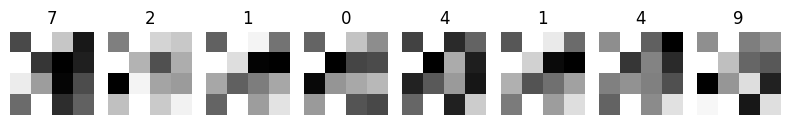

In [47]:
plot_images(LS_images, Ytst, nrows=1, ncols=8, vmin=None, vmax=None)

# Find the average latent space representation for each digit

# Decode latent space representations with the decoder

In [48]:
decoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ keras_tensor_6CLONE             │ (None, 16)             │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 196)            │         3,332 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 4)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 4)        │           148 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 7, 7, 8)        │           296 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 7, 7, 16)       │         1,168 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 14, 14, 16)     │         2,320 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 14, 14, 16)     │         2,320 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 14, 14, 16)     │         2,320 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 28, 28, 16)     │         2,320 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 28, 28, 16)     │         2,320 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_8              │ (None, 28, 28, 1)      │           145 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,689 (65.19 KB)

 Trainable params: 16,689 (65.19 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
output = decoder.predict(LS)
output.shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


(10000, 28, 28, 1)

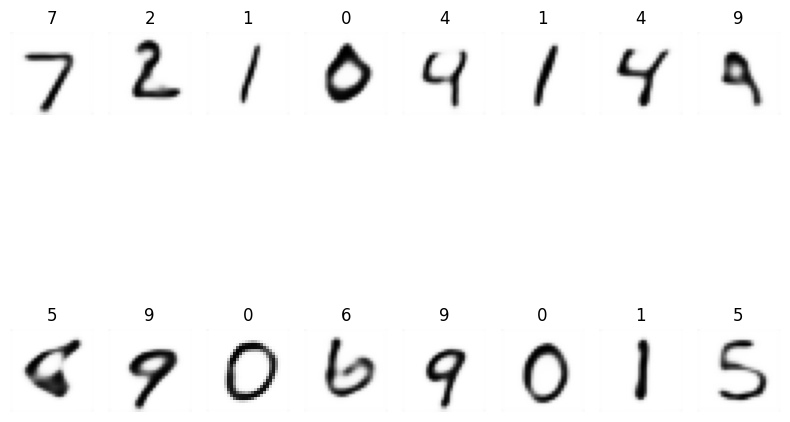

In [52]:
plot_images(output[..., 0], Ytst, nrows=2, ncols=8, vmin=None, vmax=None,)

# What if we input something in the latent space by hand and then decode it?

In [64]:
LS_manual = np.zeros_like(LS)
LS_manual.shape

LS_manual[0] = -100
LS_manual[1] = -50
LS_manual[2] = 100
LS_manual[3] = 25

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


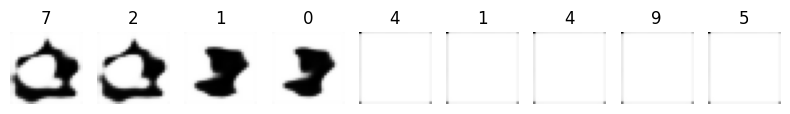

In [65]:
output = decoder.predict(LS_manual)
plot_images(output[..., 0], Ytst, nrows=1, ncols=9, vmin=None, vmax=None)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


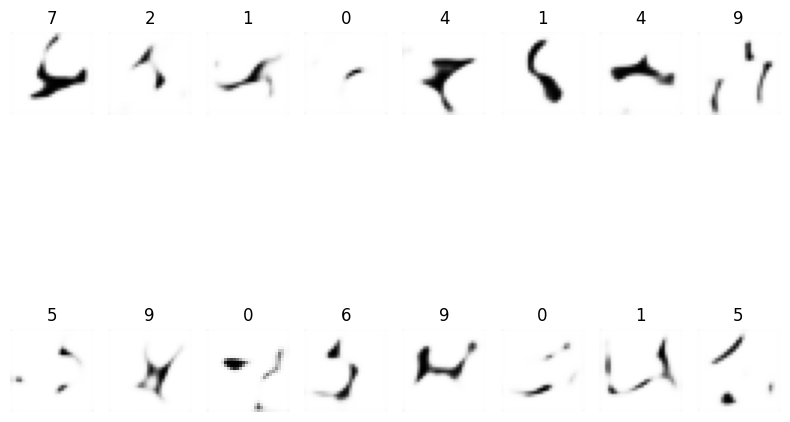

In [66]:
from scipy import stats

LS_manual = stats.uniform.rvs(loc=-10, scale=20, size=LS.shape)
output = decoder.predict(LS_manual)
plot_images(output[..., 0], Ytst, nrows=2, ncols=8, vmin=None, vmax=None)